    EXPLORATORY DATA ANALYSIS ON AI USAGE DATA

    

Importing the Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading the Data

In [2]:
df = pd.read_csv(r"C:\DATASCIENCE\MYPROJECTS\EDA_project\aiusagedata\AI_Impact_Student_Life_2026.csv")
df.head(10)

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9
5,STU-0052,19,Software Engineering,ChatGPT-4o,4,Essay Drafting,3.21,3.41,8,Medium,4
6,STU-4953,19,Business Administration,GitHub Copilot,1,Exam Prep,3.87,3.97,7,Low,1
7,STU-1723,20,Fine Arts,Perplexity,3,Exam Prep,3.18,3.08,2,Medium,9
8,STU-5100,20,Fine Arts,ChatGPT-4o,1,Literature Review,3.25,3.35,13,Medium,8
9,STU-7291,19,Fine Arts,GitHub Copilot,5,Exam Prep,3.43,3.33,10,Medium,3


Checking The Types Of Data

In [3]:
df.dtypes

Student_ID                  object
Age                          int64
Major                       object
Primary_AI_Tool             object
Task_Frequency_Daily         int64
Main_Usage_Case             object
GPA_Baseline               float64
GPA_Post_AI                float64
Time_Saved_Hours_Weekly      int64
AI_Ethics_Concern           object
Career_Confidence_Score      int64
dtype: object

Dropping Irrelavant Columns

In [4]:
df= df.drop(columns=['Student_ID'])
df.head(10)

,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9
5,19,Software Engineering,ChatGPT-4o,4,Essay Drafting,3.21,3.41,8,Medium,4
6,19,Business Administration,GitHub Copilot,1,Exam Prep,3.87,3.97,7,Low,1
7,20,Fine Arts,Perplexity,3,Exam Prep,3.18,3.08,2,Medium,9
8,20,Fine Arts,ChatGPT-4o,1,Literature Review,3.25,3.35,13,Medium,8
9,19,Fine Arts,GitHub Copilot,5,Exam Prep,3.43,3.33,10,Medium,3


Renaming Columns

In [5]:
df.rename(columns={"Main_Usage_Case": "Daily_Usage_Hours"}, inplace=True)

Dropping The Duplicate Rows

In [6]:
df.shape

(1500, 10)

In [7]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 10)


In [8]:
df.count()

Age                        1500
Major                      1500
Primary_AI_Tool            1500
Task_Frequency_Daily       1500
Daily_Usage_Hours          1500
GPA_Baseline               1500
GPA_Post_AI                1500
Time_Saved_Hours_Weekly    1500
AI_Ethics_Concern          1500
Career_Confidence_Score    1500
dtype: int64

In [9]:
df.duplicated().sum()

0

Dropping Null Values

In [10]:
print(df.isnull().sum())

Age                        0
Major                      0
Primary_AI_Tool            0
Task_Frequency_Daily       0
Daily_Usage_Hours          0
GPA_Baseline               0
GPA_Post_AI                0
Time_Saved_Hours_Weekly    0
AI_Ethics_Concern          0
Career_Confidence_Score    0
dtype: int64


Detecting Outliers

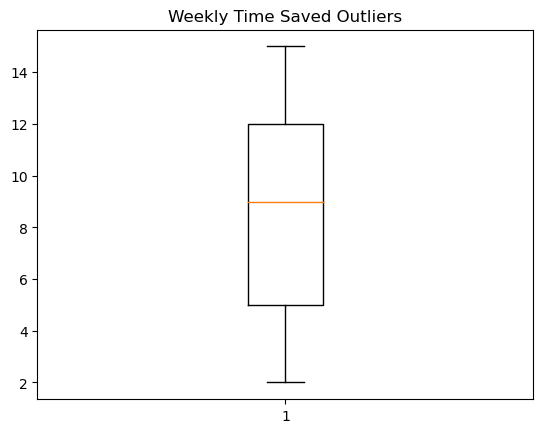

In [11]:
plt.boxplot(df["Time_Saved_Hours_Weekly"])
plt.title("Weekly Time Saved Outliers")
plt.show()

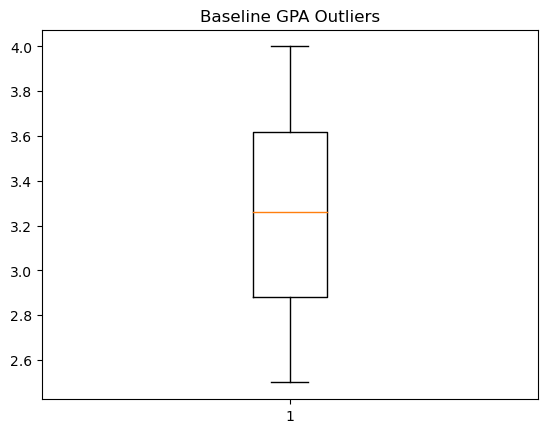

In [12]:
plt.boxplot(df["GPA_Baseline"])
plt.title("Baseline GPA Outliers")
plt.show()

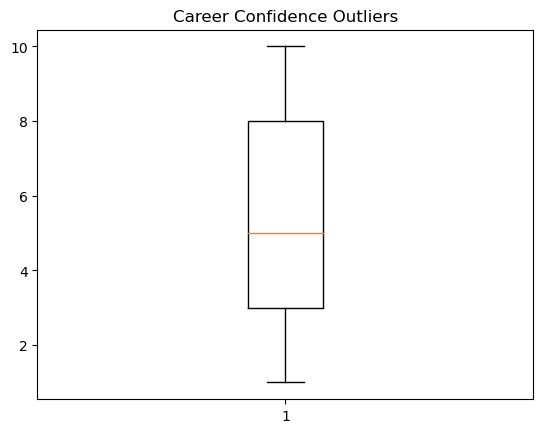

In [13]:
plt.boxplot(df["Career_Confidence_Score"])
plt.title("Career Confidence Outliers")
plt.show()

In [14]:
df.describe()

,Age,Task_Frequency_Daily,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,Career_Confidence_Score
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000
mean,21.494000,5.407333,3.256853,3.344587,8.51000,5.417333
std,2.297277,2.905462,0.430583,0.437409,4.07148,2.844977
min,18.000000,1.000000,2.500000,2.400000,2.00000,1.000000
25%,20.000000,3.000000,2.880000,2.980000,5.00000,3.000000
50%,21.000000,5.000000,3.260000,3.360000,9.00000,5.000000
75%,23.000000,8.000000,3.620000,3.710000,12.00000,8.000000
max,25.000000,10.000000,4.000000,4.000000,15.00000,10.000000


Statistical Analysis

In [15]:
num_cols = df.select_dtypes(include='number').columns
stats = df[num_cols].agg(['mean', 'median', 'std', 'min', 'max'])
stats


,Age,Task_Frequency_Daily,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,Career_Confidence_Score
mean,21.494000,5.407333,3.256853,3.344587,8.51000,5.417333
median,21.000000,5.000000,3.260000,3.360000,9.00000,5.000000
std,2.297277,2.905462,0.430583,0.437409,4.07148,2.844977
min,18.000000,1.000000,2.500000,2.400000,2.00000,1.000000
max,25.000000,10.000000,4.000000,4.000000,15.00000,10.000000


In [16]:
df.groupby('Task_Frequency_Daily').mean(numeric_only=True)


,Age,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,Career_Confidence_Score
Task_Frequency_Daily,,,,,
1,21.178344,3.244013,3.312166,8.063694,5.171975
2,21.446429,3.236548,3.322202,9.303571,5.238095
3,21.837662,3.232273,3.333182,8.577922,5.597403
4,21.653061,3.294694,3.382993,8.319728,5.571429
5,21.193548,3.286774,3.376065,8.251613,5.180645
6,21.600000,3.233857,3.303214,8.414286,5.335714
7,21.427350,3.356496,3.461111,8.487179,5.487179
8,21.500000,3.278494,3.363976,8.813253,5.819277
9,21.616883,3.224870,3.326039,8.448052,5.525974


Visualization


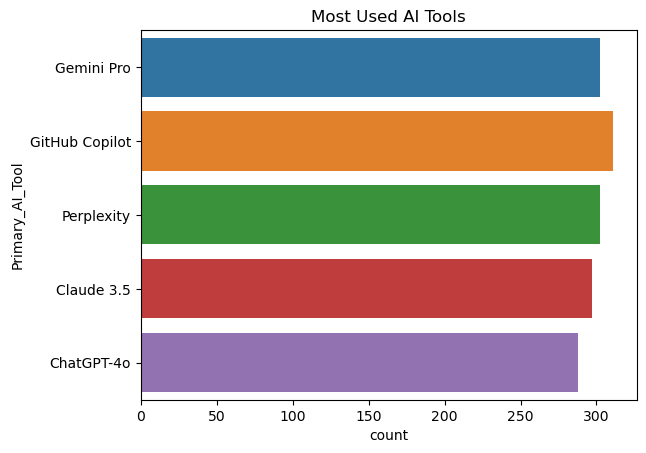

In [17]:


sns.countplot(y="Primary_AI_Tool", data=df)

plt.title("Most Used AI Tools")
plt.show()

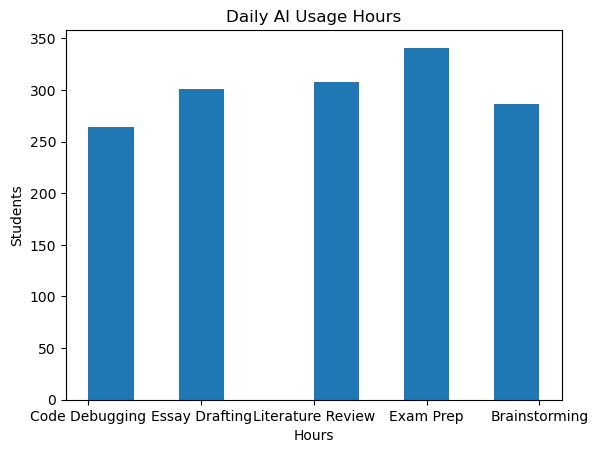

In [18]:
plt.hist(df["Daily_Usage_Hours"], bins=10)

plt.title("Daily AI Usage Hours")
plt.xlabel("Hours")
plt.ylabel("Students")
plt.show()

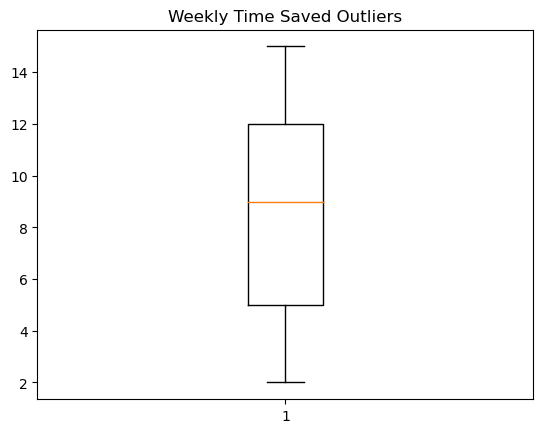

In [19]:
plt.boxplot(df["Time_Saved_Hours_Weekly"])

plt.title("Weekly Time Saved Outliers")
plt.show()

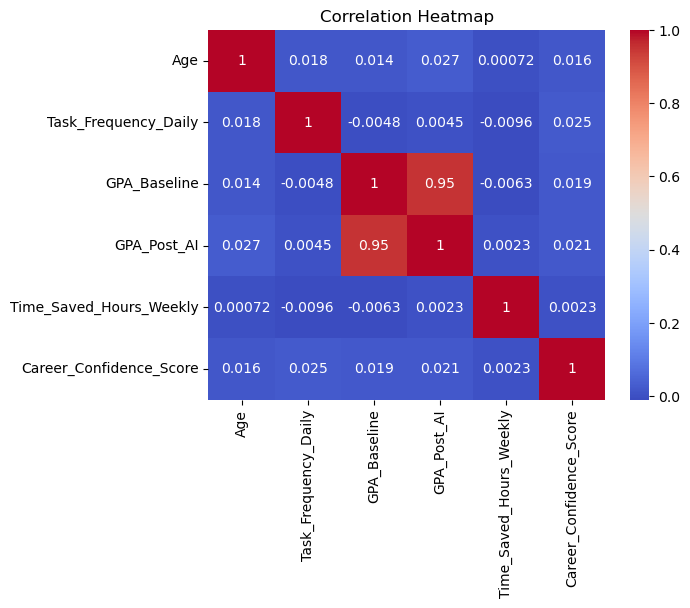

In [20]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

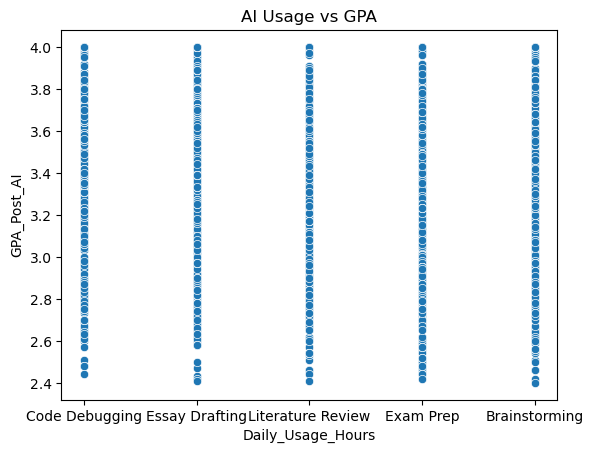

In [21]:
sns.scatterplot(
    x="Daily_Usage_Hours",
    y="GPA_Post_AI",
    data=df
)

plt.title("AI Usage vs GPA")
plt.show()

In [22]:
df["GPA_Improvement"] = (
    df["GPA_Post_AI"] - df["GPA_Baseline"]
)

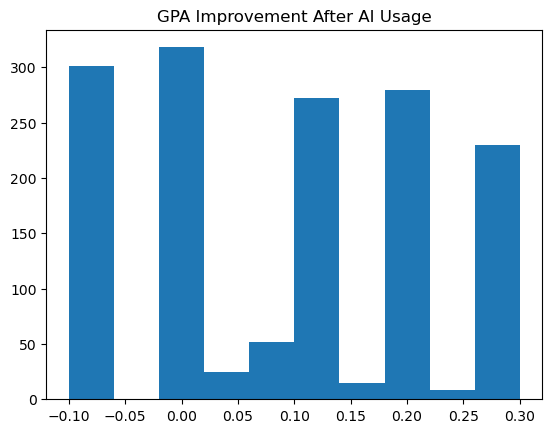

In [23]:
plt.hist(df["GPA_Improvement"], bins=10)

plt.title("GPA Improvement After AI Usage")
plt.show()

Conclusion

This exploratory data analysis of AI usage among students in 2026 revealed that AI tools — particularly a few dominant platforms — are widely adopted for daily academic tasks. Most students report moderate daily usage and consistent weekly time savings. While the majority showed a slight improvement in GPA after incorporating AI, usage hours alone did not strongly predict academic performance, suggesting that how students use AI matters more than how much. Career confidence scores were generally positive, indicating that AI exposure contributes to students' sense of future readiness. Overall, the data suggests AI has a meaningful but nuanced impact on student life — beneficial when used purposefully, with a small subset of students showing no improvement or lower confidence despite usage.